<a href="https://colab.research.google.com/github/muiddd/5thSemester_PCVK/blob/main/Week05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

NAMA : Abdul Muid
NIM : 244107020006 | N = 6
bins   : 32
clip   : 1.5
tile   : 4
L      : 2
WAKTU : 2026-10-05 07:49:35 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 7ac24d12d66a6605


Text(0.5, 1.0, '244107020006 - CLAHE clip 1.5')

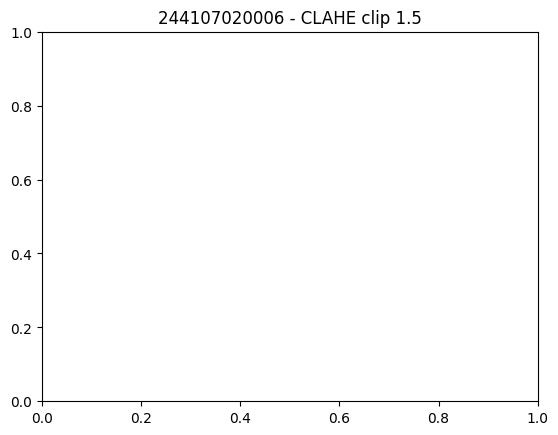

In [3]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Abdul Muid'
NIM = '244107020006'

N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))

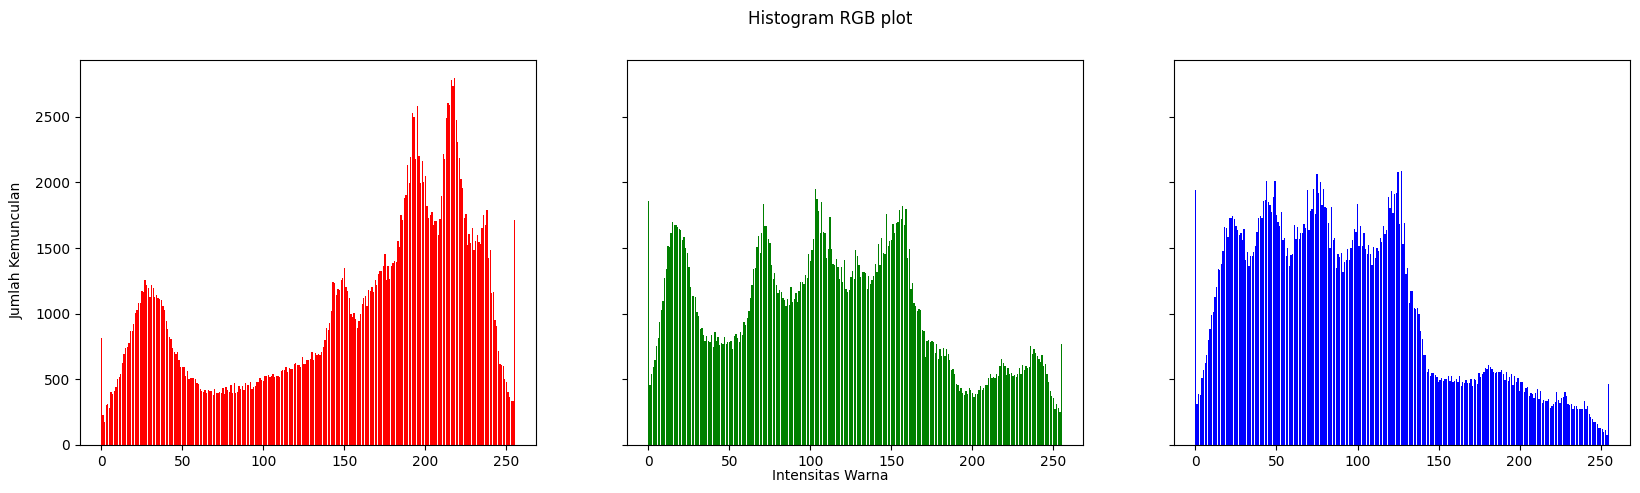

In [4]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

In [5]:
# Load gambar lena.jpg dalam format grayscale agar lebih mudah untuk perbandingan dasar
img_lena = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg', cv.IMREAD_GRAYSCALE)

# 1. Cara Manual (Looping tiap piksel)
hist_manual = np.zeros(256, dtype=int)
for y in range(img_lena.shape[0]):
    for x in range(img_lena.shape[1]):
        hist_manual[img_lena[y, x]] += 1

# 2. Cara NumPy
# flatten() digunakan untuk mengubah array 2D menjadi 1D agar bisa dihitung histogramnya
hist_np, _ = np.histogram(img_lena.flatten(), bins=256, range=[0, 256])

# 3. Cara OpenCV
# calcHist mengembalikan array 2D (tipe float32), jadi harus di-flatten() agar ukurannya sejajar (1D)
hist_cv = cv.calcHist([img_lena], [0], None, [256], [0, 256])
hist_cv = hist_cv.flatten()

# --- PEMBUKTIAN ---
# np.abs() untuk mempositifkan nilai minus (nilai absolut)
# np.max() untuk mencari angka selisih terbesar dari 256 elemen
diff_manual_np = np.max(np.abs(hist_manual - hist_np))
diff_np_cv = np.max(np.abs(hist_np - hist_cv))

print("=== Hasil Pembuktian lena.jpg ===")
print(f"Selisih maksimum Manual vs NumPy  : {diff_manual_np}")
print(f"Selisih maksimum NumPy vs OpenCV  : {diff_np_cv}")

=== Hasil Pembuktian lena.jpg ===
Selisih maksimum Manual vs NumPy  : 0
Selisih maksimum NumPy vs OpenCV  : 0.0


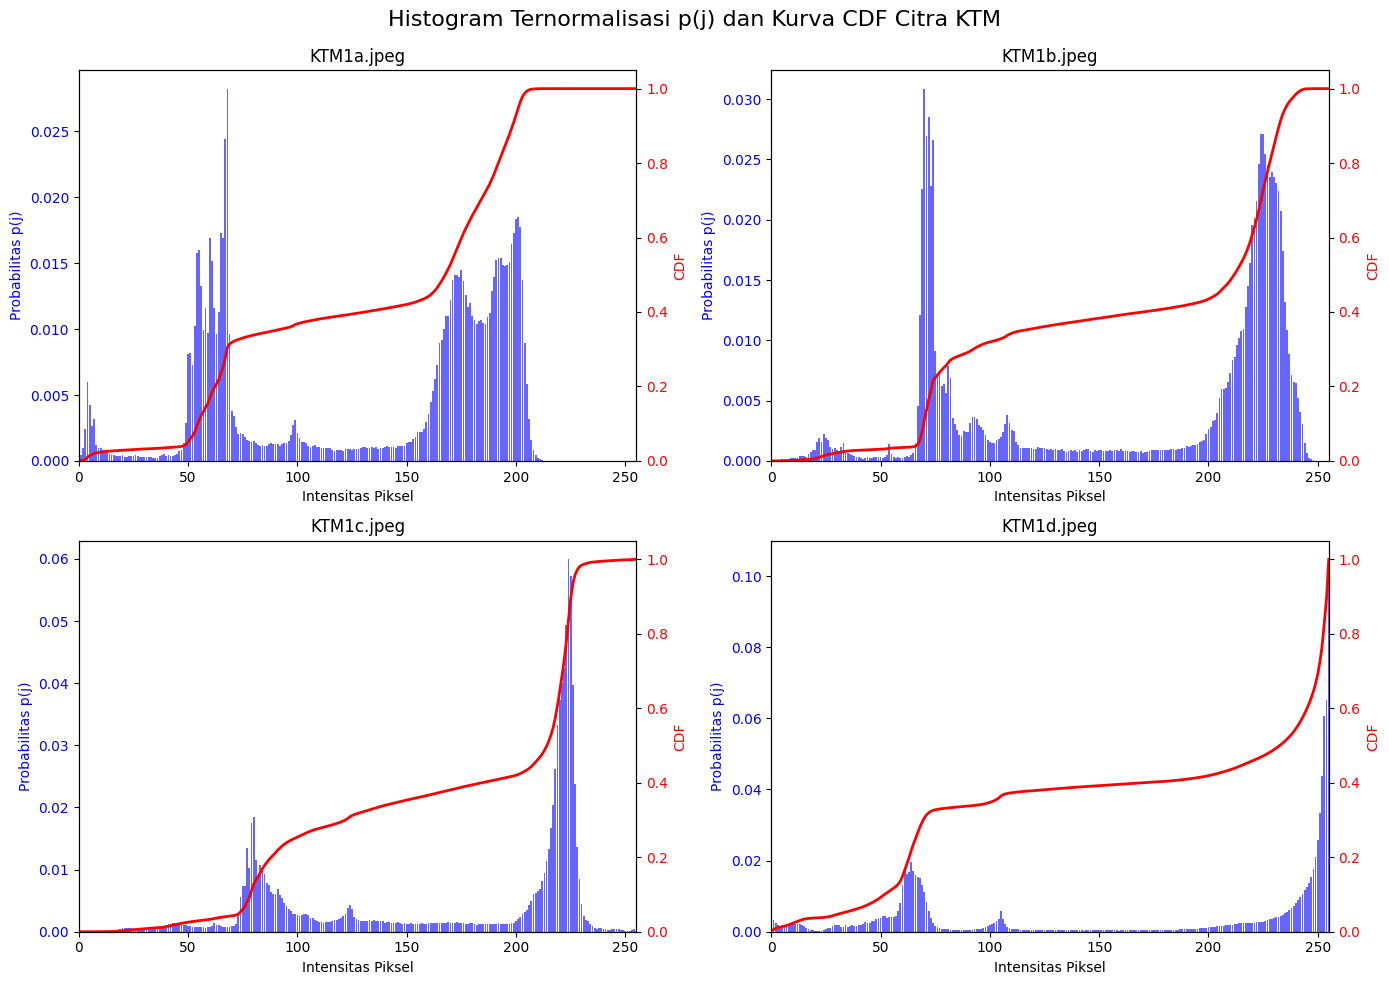

In [8]:
import glob
import os

# Menggunakan * untuk mengambil semua file .jpg atau .jpeg di dalam folder
path_ktm = '/content/drive/MyDrive/PCVK/KTM/*'
daftar_file = sorted(glob.glob(path_ktm))

# Pastikan file ditemukan
if len(daftar_file) == 0:
    print("Gagal: Tidak ada file gambar yang ditemukan di dalam folder tersebut.")
else:
    # Mengambil maksimal 4 file pertama
    daftar_file = daftar_file[:4]

    # Membuat figure 2x2
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Histogram Ternormalisasi p(j) dan Kurva CDF Citra KTM', fontsize=16)
    axs = axs.ravel()

    for i, file_path in enumerate(daftar_file):
        # Membaca citra
        img = cv.imread(file_path, cv.IMREAD_GRAYSCALE)

        # Mengambil nama file asli dari path (misal: KTM1a.jpg) untuk judul
        nama_file = os.path.basename(file_path)

        if img is None:
            axs[i].text(0.5, 0.5, f"Gagal membaca file:\n{nama_file}", ha='center', va='center')
            continue

        # 1. Menghitung histogram biasa
        hist, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])

        # 2. Normalisasi histogram p(j)
        p_j = hist / img.size

        # 3. Menghitung CDF
        cdf = p_j.cumsum()

        # Plot Histogram p(j) - Sumbu kiri
        axs[i].bar(np.arange(256), p_j, color='blue', alpha=0.6, label='p(j)')
        axs[i].set_xlabel('Intensitas Piksel')
        axs[i].set_ylabel('Probabilitas p(j)', color='blue')
        axs[i].tick_params(axis='y', labelcolor='blue')

        # Plot Kurva CDF - Sumbu kanan
        ax2 = axs[i].twinx()
        ax2.plot(cdf, color='red', linewidth=2, label='CDF')
        ax2.set_ylabel('CDF', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        axs[i].set_title(nama_file)
        axs[i].set_xlim([0, 255])
        ax2.set_ylim([0, 1.05])

    # Jika file yang ditemukan kurang dari 4, kosongkan subplot sisanya
    for j in range(i + 1, 4):
        fig.delaxes(axs[j])

    plt.tight_layout()
    fig.subplots_adjust(top=0.92)
    plt.show()

NIM Anda: 244107020006, Nilai N: 6
Jumlah Bins yang digunakan (PARAM['bins']): 32
--------------------------------------------------


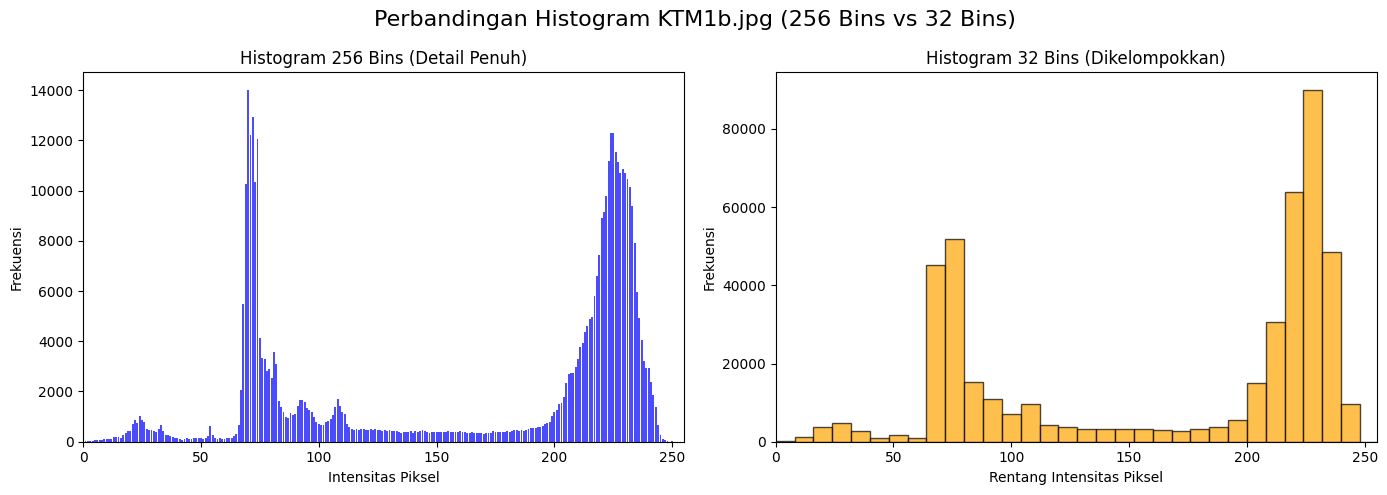

In [14]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# --- 1. DEFINISI PARAMETER BERDASARKAN NIM ---
NIM = '244107020006'
N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    # Parameter lain yang akan dipakai di percobaan selanjutnya
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

print(f"NIM Anda: {NIM}, Nilai N: {N}")
print(f"Jumlah Bins yang digunakan (PARAM['bins']): {PARAM['bins']}")
print("-" * 50)

# --- 2. KODE PERBANDINGAN HISTOGRAM ---
path_ktm1b = '/content/drive/MyDrive/PCVK/KTM/KTM1b.jpeg'
img_ktm1b = cv.imread(path_ktm1b, cv.IMREAD_GRAYSCALE)

if img_ktm1b is None:
    print("Gambar KTM1b.jpg tidak ditemukan. Pastikan path sudah benar.")
else:
    jml_bins = PARAM['bins']

    # Membuat figure untuk membandingkan 2 histogram berdampingan
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Perbandingan Histogram KTM1b.jpg (256 Bins vs {jml_bins} Bins)", fontsize=16)

    # Histogram Kiri: 256 Bins
    hist_256, _ = np.histogram(img_ktm1b.flatten(), bins=256, range=[0, 256])
    axs[0].bar(np.arange(256), hist_256, color='blue', alpha=0.7)
    axs[0].set_title('Histogram 256 Bins (Detail Penuh)')
    axs[0].set_xlabel('Intensitas Piksel')
    axs[0].set_ylabel('Frekuensi')
    axs[0].set_xlim([0, 255])

    # Histogram Kanan: PARAM['bins']
    hist_param, batas_bins = np.histogram(img_ktm1b.flatten(), bins=jml_bins, range=[0, 256])

    # Menghitung lebar setiap batang berdasarkan batas_bins
    lebar_bin = np.diff(batas_bins)

    # Plot dengan memberikan garis tepi (edgecolor) agar batas kelompok bin terlihat jelas
    axs[1].bar(batas_bins[:-1], hist_param, width=lebar_bin, color='orange', alpha=0.7, align='edge', edgecolor='black')
    axs[1].set_title(f"Histogram {jml_bins} Bins (Dikelompokkan)")
    axs[1].set_xlabel('Rentang Intensitas Piksel')
    axs[1].set_ylabel('Frekuensi')
    axs[1].set_xlim([0, 255])

    plt.tight_layout()
    plt.show()